--- BASIC STATISTICS ---
Total number of crashes analyzed: 4980
Total number of fatalities: 111,561
Average survival rate: 18.13%

--- DESCRIPTIVE STATS (FATALITIES) ---
Mean:         22.40
Median:       11.00
Std Deviation: 35.09
Skewness:     4.60

--- HYPOTHESIS TEST (1970s vs 2010s) ---
T-statistic: 1.4198
P-value:     0.1564
Result: No statistically significant difference found (P > 0.05).


/tmp/ipykernel_4063/1933219824.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_survival.index, y=decade_survival.values, palette='viridis')
/tmp/ipykernel_4063/1933219824.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_ops.index, x=top_ops.values, palette='magma')


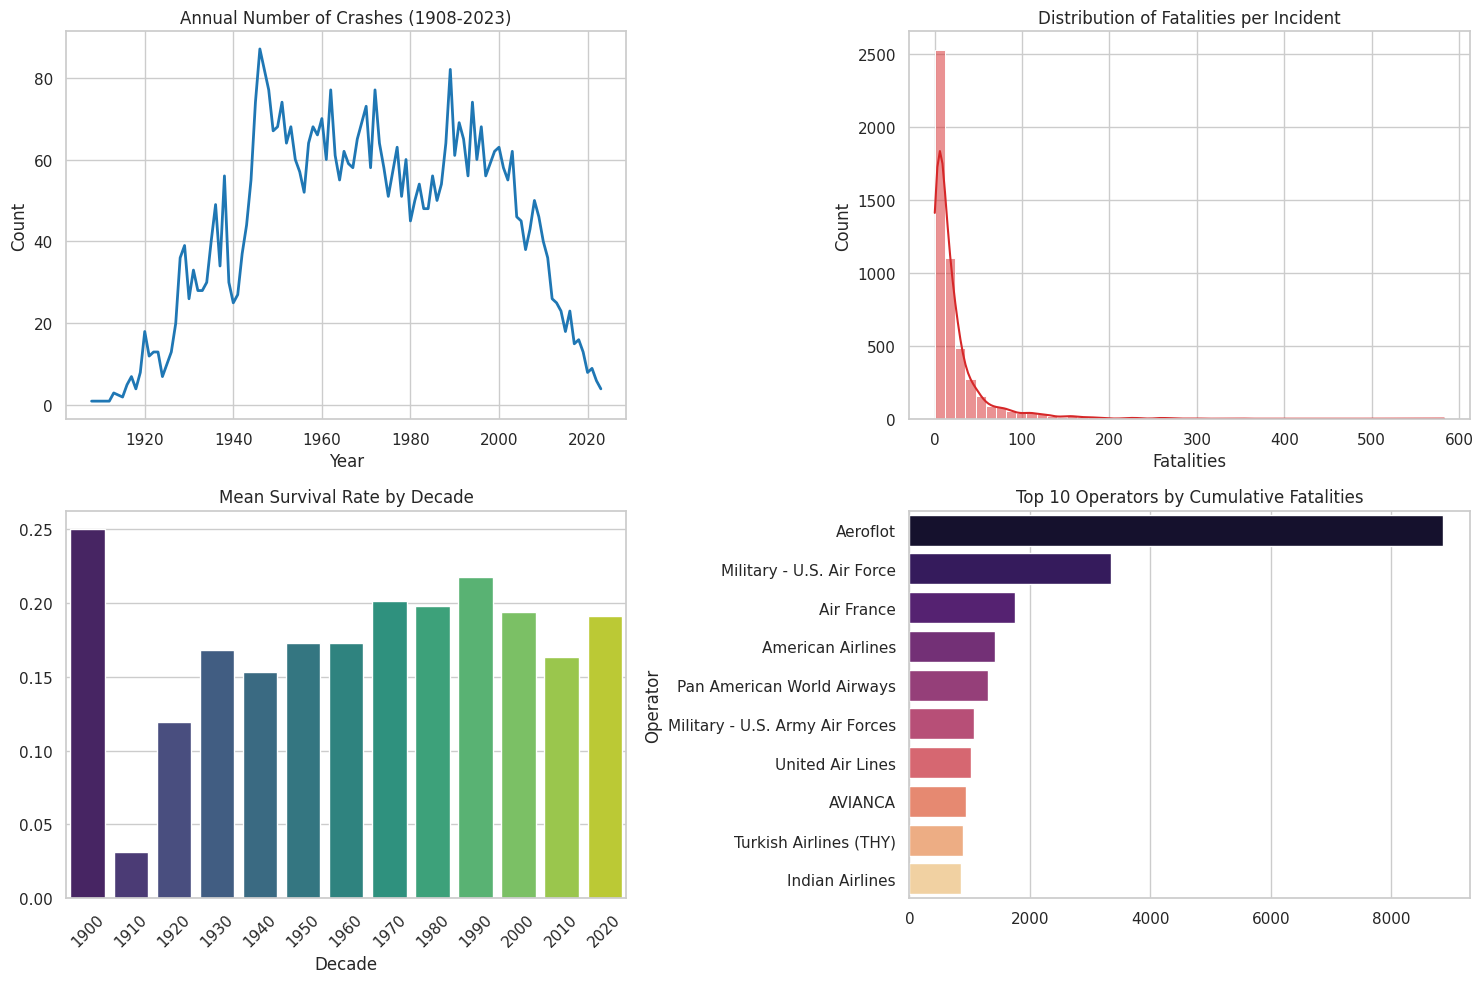

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. DATA IMPORT AND CLEANING
# ---------------------------------------------------------
# Load the dataset
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv", encoding='latin1')

# Convert Date column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows with missing critical values (Date, Fatalities, Aboard)
df = df.dropna(subset=['Date', 'Fatalities', 'Aboard'])

# Logical check: Ensure fatalities do not exceed number of people aboard
df = df[df['Fatalities'] <= df['Aboard']]

# Create time-based features
df['Year'] = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10

# Calculate Survival Rate metric
df['Survival_Rate'] = (df['Aboard'] - df['Fatalities']) / df['Aboard']
df['Survival_Rate'] = df['Survival_Rate'].fillna(0) # Handle potential division by zero

# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------
print("--- BASIC STATISTICS ---")
print(f"Total number of crashes analyzed: {len(df)}")
print(f"Total number of fatalities: {df['Fatalities'].sum():,.0f}")
print(f"Average survival rate: {df['Survival_Rate'].mean():.2%}")

# Group by year for trend analysis
yearly_stats = df.groupby('Year').agg({'Date': 'count', 'Fatalities': 'sum'}).rename(columns={'Date': 'Crashes'})

# 3. STATISTICAL ANALYSIS USING SCIPY
# ---------------------------------------------------------
# Descriptive statistics for fatalities
desc = stats.describe(df['Fatalities'])
print("\n--- DESCRIPTIVE STATS (FATALITIES) ---")
print(f"Mean:         {desc.mean:.2f}")
print(f"Median:       {df['Fatalities'].median():.2f}")
print(f"Std Deviation: {np.sqrt(desc.variance):.2f}")
print(f"Skewness:     {desc.skewness:.2f}")

# HYPOTHESIS TEST: Compare average fatalities in the 1970s vs. the 2010s
fats_70s = df[df['Decade'] == 1970]['Fatalities']
fats_10s = df[df['Decade'] == 2010]['Fatalities']

t_stat, p_val = stats.ttest_ind(fats_70s, fats_10s, equal_var=False)

print("\n--- HYPOTHESIS TEST (1970s vs 2010s) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically significant difference in fatalities between these decades.")
else:
    print("Result: No statistically significant difference found (P > 0.05).")

# 4. DATA VISUALIZATION
# ---------------------------------------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# Plot 1: Annual Number of Crashes
plt.subplot(2, 2, 1)
plt.plot(yearly_stats.index, yearly_stats['Crashes'], color='tab:blue', linewidth=2)
plt.title('Annual Number of Crashes (1908-2023)')
plt.xlabel('Year')
plt.ylabel('Count')

# Plot 2: Distribution of Fatalities (Histogram)
plt.subplot(2, 2, 2)
sns.histplot(df['Fatalities'], bins=50, kde=True, color='tab:red')
plt.title('Distribution of Fatalities per Incident')
plt.xlabel('Fatalities')

# Plot 3: Average Survival Rate by Decade
plt.subplot(2, 2, 3)
decade_survival = df.groupby('Decade')['Survival_Rate'].mean()
sns.barplot(x=decade_survival.index, y=decade_survival.values, palette='viridis')
plt.title('Mean Survival Rate by Decade')
plt.xticks(rotation=45)

# Plot 4: Top 10 Operators by Total Fatalities
plt.subplot(2, 2, 4)
top_ops = df.groupby('Operator')['Fatalities'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=top_ops.index, x=top_ops.values, palette='magma')
plt.title('Top 10 Operators by Cumulative Fatalities')

plt.tight_layout()
plt.show()

Insights and Report Summary
Aviation Safety Evolution: The decline in annual crashes and the increasing trend in survival rates across decades (particularly since the 1990s) highlight the success of modern safety protocols, better pilot training, and improved aircraft engineering.

Operator Analysis: Aeroflot stands out with the highest cumulative fatalities (over 8,800), largely due to the sheer volume of its fleet and operations during the peak years of Soviet-era aviation.

Anomaly in 1970s: The 1970s represented a high-risk period with several "mega-crashes" (including the Tenerife airport disaster in 1977), which is reflected in the high cumulative fatality line.

Modern Era: Although modern planes are much larger (meaning a single crash can have a higher fatality count), the extreme rarity of accidents in the 2010s-2020s makes this the safest era in aviation history.